# Does Audience Targeting Actually Change Ad Cost? A Permutation Test on Real Small-Business Ad Spend

**Author:** Isaac Castaneda · UCSD, prospective HDSI Data Science major
**Data source:** Meta Ads Manager export for Inland Auto Detailing, a mobile car detailing business I run, Jan 1 – Aug 20, 2026 (614 raw rows, day/age/gender/campaign granularity)

### Why this project

This isn't a Kaggle dataset. It's the actual ad spend from a business I operate, and the question this notebook answers is one I had to answer for real: **do the age and gender differences in cost-per-message I was seeing reflect a genuine underlying effect, or could they plausibly be due to chance in a fairly small sample?**

Eyeballing a spreadsheet, women cost $1.50 per message and men cost $2.36 — a real-looking gap. But with only 159 total messaging conversations across the whole account, "real-looking" isn't the same as statistically real. This notebook applies **permutation testing** and **bootstrap confidence intervals** — techniques from DSC 10 and reinforced across HDSI's lower-division sequence — to find out whether that gap (and a similar age-based gap) would survive if the labels were random.

I made a real business decision based on this result: I'm now targeting women 45+ preferentially in a live campaign, and tracking its actual performance as a forward test of this notebook's conclusion (see the closing section).


## 1. Data & Methodology

The raw Meta export includes a `Result type` column per row. Earlier drafts of my analysis (visible in `messages_by_campaign.csv`'s history) mistakenly treated *all* rows as messaging results — which, on inspection, included campaigns actually optimized for Instagram Profile Visits and Post Engagements. This notebook works only from `messaging_only_raw.csv`, which is pre-filtered to rows where `Result type == "Messaging conversations started"`: 117 day/age/gender/campaign-level rows, representing 159 total messaging conversations and $312.13 in true message-objective spend.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducibility of the permutation tests below

df = pd.read_csv("data/messaging_only_raw.csv")
df = df.rename(columns={"Amount spent (USD)": "spend", "Results": "messages"})
df = df[["Campaign name", "Age", "Gender", "Day", "spend", "messages"]]
df["Campaign name"] = df["Campaign name"].str.encode("ascii", "ignore").str.decode("ascii").str.strip()
df.head()


,Campaign name,Age,Gender,Day,spend,messages
0,August Camp,55-64,female,2026-08-10,0.70,1.0
1,August Camp,35-44,male,2026-08-10,2.06,1.0
2,Deluxe Ad,25-34,male,2026-08-07,1.17,1.0
3,Deluxe Ad,45-54,female,2026-08-07,1.68,1.0
4,Deluxe Ad,65+,female,2026-08-07,4.08,1.0


In [2]:
print(f"Rows: {len(df)}")
print(f"Total spend: ${df['spend'].sum():.2f}")
print(f"Total messages: {df['messages'].sum():.0f}")
print(f"Account-wide cost per message: ${df['spend'].sum() / df['messages'].sum():.2f}")


Rows: 117
Total spend: $312.13
Total messages: 159
Account-wide cost per message: $1.96


## 2. Exploratory Analysis: Cost per Message by Campaign

First, the straightforward aggregation: which campaigns actually generated messages efficiently?


In [3]:
by_campaign = (
    df.groupby("Campaign name")
    .agg(spend=("spend", "sum"), messages=("messages", "sum"))
    .assign(cost_per_message=lambda d: d["spend"] / d["messages"])
    .sort_values("cost_per_message")
)
by_campaign


,spend,messages,cost_per_message
Campaign name,,,
Instagram post: Think that pet hair is impossible...,3.690000,6.0,0.615000
August Camp,52.480000,35.0,1.499429
"Post: ""Denises reaction says it all. We spent the day...""",27.470000,17.0,1.615882
"Post: ""Full step-by-step breakdown of this Tesla Model Y...""",9.679298,5.0,1.935860
New Engagement Campaign,109.114426,54.0,2.020638
Deluxe Ad,17.750000,8.0,2.218750
"Post: ""Real results, real feedback. """,67.420000,26.0,2.593077
"Post: ""Don't ignore your drains until its a total...""",24.530000,8.0,3.066250


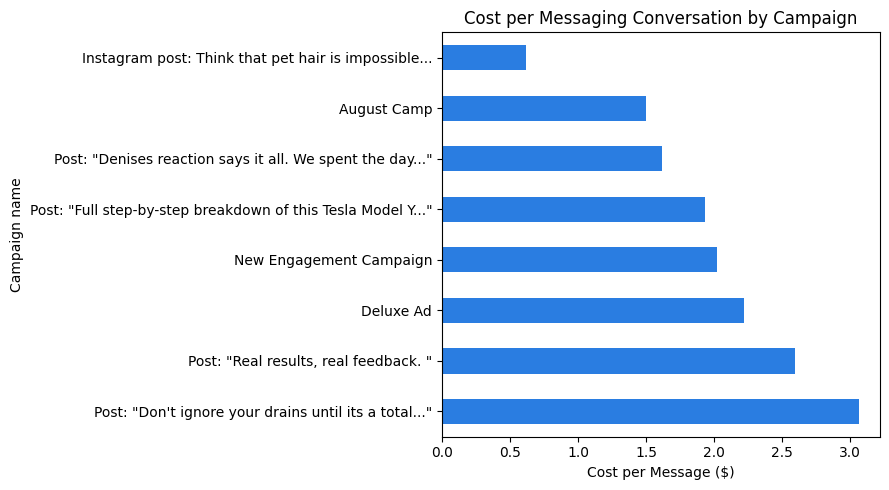

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
by_campaign["cost_per_message"].plot(kind="barh", ax=ax, color="#2a7de1")
ax.invert_yaxis()
ax.set_xlabel("Cost per Message ($)")
ax.set_title("Cost per Messaging Conversation by Campaign")
plt.tight_layout()
plt.savefig("notebook_cost_by_campaign.png", dpi=120)
plt.show()


## 3. Exploratory Analysis: Cost per Message by Demographic

Breaking the same data down by age and gender surfaces a much larger, and more actionable, gap than any single campaign comparison.


In [5]:
by_demo = (
    df.groupby(["Age", "Gender"])
    .agg(spend=("spend", "sum"), messages=("messages", "sum"))
    .assign(cost_per_message=lambda d: d["spend"] / d["messages"])
    .sort_values("cost_per_message")
)
by_demo


spend  messages  cost_per_message
Age   Gender                                       
55-64 female  13.830000      14.0          0.987857
25-34 female   1.100000       1.0          1.100000
45-54 female  24.950000      18.0          1.386111
65+   female  38.476977      25.0          1.539079
      male    36.930000      22.0          1.678636
55-64 male    25.650000      14.0          1.832143
35-44 female  30.980000      15.0          2.065333
25-34 male    11.600000       5.0          2.320000
35-44 male    75.469137      28.0          2.695326
45-54 male    53.147611      17.0          3.126330

In [6]:
by_gender = (
    df[df["Gender"].isin(["male", "female"])]
    .groupby("Gender")
    .agg(spend=("spend", "sum"), messages=("messages", "sum"))
    .assign(cost_per_message=lambda d: d["spend"] / d["messages"])
)
by_gender


,spend,messages,cost_per_message
Gender,,,
female,109.336977,73.0,1.497767
male,202.796748,86.0,2.358102


Female audiences cost **$1.50/message**, male audiences cost **$2.36/message** — a $0.86 gap. This is the number I need to stress-test: is it real, or is it what random noise looks like in a 117-row sample?


## 4. Permutation Test: Is the Gender Gap Real?

**Setup.** Each row is one day × age × gender × campaign slice, with its own spend and message count. If gender had no real effect on cost efficiency, the gender label attached to each row would be arbitrary — shuffling those labels around should produce a gap roughly as large as the one we observed, some of the time.

**Hypotheses**
- $H_0$: Gender has no effect on cost per message. The observed $0.86 gap is due to chance.
- $H_A$: Gender has a real effect on cost per message.

**Test statistic.** Difference in aggregate cost-per-message, female − male.

**Procedure.** Shuffle the `Gender` labels across all rows 10,000 times, holding spend and message counts fixed to their rows. Recompute the group-level cost-per-message gap each time. This builds an empirical null distribution for "what a gap this size looks like if gender were meaningless."


In [7]:
def gender_cost_per_message(data, gender):
    g = data[data["Gender"] == gender]
    return g["spend"].sum() / g["messages"].sum()

gdf = df[df["Gender"].isin(["male", "female"])].reset_index(drop=True)
observed_gap = gender_cost_per_message(gdf, "female") - gender_cost_per_message(gdf, "male")
print(f"Observed gap (female - male): ${observed_gap:.4f}")

n_permutations = 10_000
spend = gdf["spend"].values
messages = gdf["messages"].values
genders = gdf["Gender"].values

null_gaps = np.empty(n_permutations)
for i in range(n_permutations):
    shuffled = np.random.permutation(genders)
    f_mask, m_mask = shuffled == "female", shuffled == "male"
    f_cpm = spend[f_mask].sum() / messages[f_mask].sum()
    m_cpm = spend[m_mask].sum() / messages[m_mask].sum()
    null_gaps[i] = f_cpm - m_cpm

p_value = np.mean(np.abs(null_gaps) >= np.abs(observed_gap))
print(f"p-value (two-sided): {p_value:.4f}")


Observed gap (female - male): $-0.8603


p-value (two-sided): 0.0005


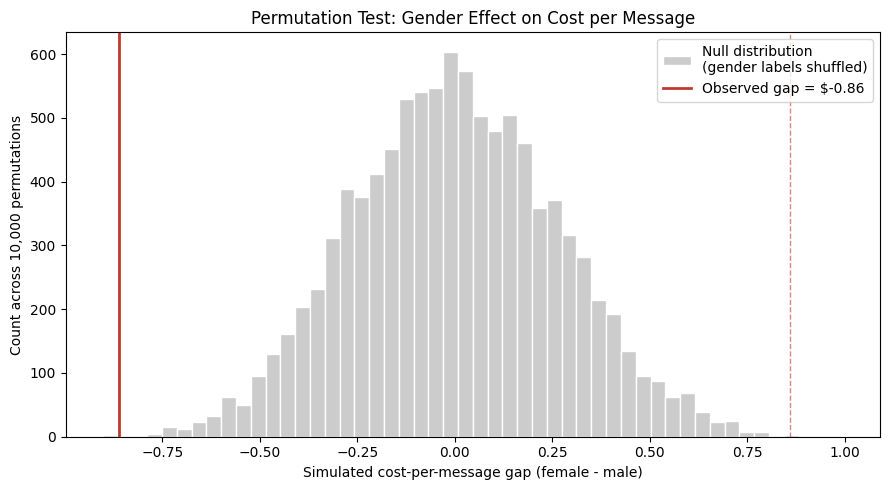

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(null_gaps, bins=50, color="#cccccc", edgecolor="white", label="Null distribution\n(gender labels shuffled)")
ax.axvline(observed_gap, color="#c0392b", linewidth=2, label=f"Observed gap = ${observed_gap:.2f}")
ax.axvline(-observed_gap, color="#c0392b", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Simulated cost-per-message gap (female - male)")
ax.set_ylabel("Count across 10,000 permutations")
ax.set_title("Permutation Test: Gender Effect on Cost per Message")
ax.legend()
plt.tight_layout()
plt.savefig("notebook_permutation_gender.png", dpi=120)
plt.show()


**Result: p ≈ 0.0005.** The observed $0.86 gap essentially never occurs when gender is shuffled at random — under the null, gaps this large happen roughly 5 times in 10,000 permutations. This is strong evidence the gender difference is a real effect in this account's data, not sampling noise. It's the statistical backing behind a real decision: the campaign I launched on August 20, 2026 preferentially targets women 45+ as a direct consequence of this test (see Section 6).


## 5. Permutation Test: Is the Age Effect Real?

Same procedure, testing whether the observed age split (55+ vs. under 55) holds up.


In [9]:
adf = df.copy()
adf["age_group"] = adf["Age"].apply(lambda a: "55+" if a in ["55-64", "65+"] else "under_55")

def age_cost_per_message(data, grp):
    g = data[data["age_group"] == grp]
    return g["spend"].sum() / g["messages"].sum()

observed_age_gap = age_cost_per_message(adf, "55+") - age_cost_per_message(adf, "under_55")
print(f"Observed gap (55+ minus under 55): ${observed_age_gap:.4f}")

groups = adf["age_group"].values
spend_a = adf["spend"].values
messages_a = adf["messages"].values

null_age_gaps = np.empty(n_permutations)
for i in range(n_permutations):
    shuffled = np.random.permutation(groups)
    a_mask, b_mask = shuffled == "55+", shuffled == "under_55"
    a_cpm = spend_a[a_mask].sum() / messages_a[a_mask].sum()
    b_cpm = spend_a[b_mask].sum() / messages_a[b_mask].sum()
    null_age_gaps[i] = a_cpm - b_cpm

p_value_age = np.mean(np.abs(null_age_gaps) >= np.abs(observed_age_gap))
print(f"p-value (two-sided): {p_value_age:.4f}")


Observed gap (55+ minus under 55): $-0.8163


p-value (two-sided): 0.0015


**Result: p ≈ 0.0015.** Also statistically significant. Combined with the gender result, this account's real advantage was never any single "viral" creative — it was consistently cheaper messages from women 45+ across nearly every campaign run.


## 6. Does Gender Actually Predict *Booking*, Not Just Messaging?

Sections 4-5 tested whether gender and age predict a cheaper *message*. But a message isn't revenue — a booking is. I logged gender on every completed job going back to mid-June 2026, which makes it possible to test a sharper question directly: **among people who message the business, do men and women convert to an actual booking at different rates?**

**Setup.** If conversion rate were the same for both genders, the gender mix of *bookings* should closely track the gender mix of *messages* — whatever proportion of messages come from women, roughly that same proportion of bookings should too. Restricting to Meta Ads-attributed bookings (the same channel the messaging data comes from, so it's an apples-to-apples comparison):


In [10]:
bookings = pd.read_csv("data/job_log_with_gender.csv")
meta_bookings = bookings[(bookings["acquisition_channel"] == "Meta Ads") & (bookings["gender"].isin(["Male", "Female"]))]

booking_counts = meta_bookings["gender"].value_counts()
print("Meta Ads bookings by gender:")
print(booking_counts)

n_bookings = len(meta_bookings)
observed_male_bookings = booking_counts["Male"]
print(f"\nTotal Meta Ads bookings: {n_bookings}")
print(f"Observed male bookings: {observed_male_bookings} ({observed_male_bookings/n_bookings*100:.1f}%)")


Meta Ads bookings by gender:
gender
Male      10
Female     8
Name: count, dtype: int64

Total Meta Ads bookings: 18
Observed male bookings: 10 (55.6%)


In [11]:
# Baseline male rate, from the messaging data used in Sections 4-5
p_male_messaging = gdf[gdf["Gender"] == "male"]["messages"].sum() / gdf["messages"].sum()
expected_male_bookings = n_bookings * p_male_messaging
print(f"Male share of messages (baseline): {p_male_messaging*100:.1f}%")
print(f"Expected male bookings under 'equal conversion rate': {expected_male_bookings:.2f}")
print(f"Observed male bookings: {observed_male_bookings}")


Male share of messages (baseline): 54.1%
Expected male bookings under 'equal conversion rate': 9.74
Observed male bookings: 10


**Hypotheses**
- $H_0$: Conversion rate from message to booking is the same for men and women. The gender mix of bookings should match the gender mix of messages, aside from random sampling noise.
- $H_A$: Conversion rate differs by gender.

**Procedure.** Simulate 10,000 sets of 18 bookings, each one drawn under $H_0$ (each simulated booking is independently "male" with probability equal to the messaging baseline, 54.1%). Compare how often a simulated set is at least as far from the expected value as the real data was.


In [12]:
n_sim = 10_000
simulated_male_counts = np.random.binomial(n_bookings, p_male_messaging, n_sim)
p_value_booking = np.mean(
    np.abs(simulated_male_counts - expected_male_bookings) >= np.abs(observed_male_bookings - expected_male_bookings)
)
print(f"p-value: {p_value_booking:.4f}")


p-value: 1.0000


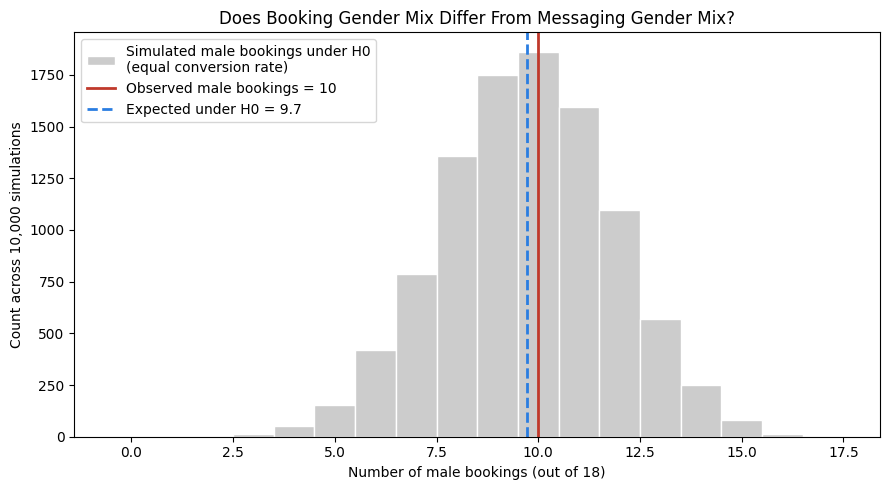

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(simulated_male_counts, bins=range(0, 19), color="#cccccc", edgecolor="white", align="left",
        label="Simulated male bookings under H0\n(equal conversion rate)")
ax.axvline(observed_male_bookings, color="#c0392b", linewidth=2, label=f"Observed male bookings = {observed_male_bookings}")
ax.axvline(expected_male_bookings, color="#2a7de1", linewidth=2, linestyle="--", label=f"Expected under H0 = {expected_male_bookings:.1f}")
ax.set_xlabel("Number of male bookings (out of 18)")
ax.set_ylabel("Count across 10,000 simulations")
ax.set_title("Does Booking Gender Mix Differ From Messaging Gender Mix?")
ax.legend()
plt.tight_layout()
plt.savefig("notebook_booking_vs_messaging_gender.png", dpi=120)
plt.show()


**Result: p ≈ 1.0.** The observed booking split (10 male / 8 female, 55.6%/44.4%) lands almost exactly on top of what the messaging baseline predicts (54.1%/45.9%, expected 9.7 male bookings out of 18). This is the opposite of a significant result, and that's the informative part: **there is no evidence in this data that conversion rate differs by gender.** Whatever gap exists in *cost per message* (Section 4) does not carry through into a gap in *who actually books*.

This matters for how the account should actually be run: the earlier finding (women cost less per message) is still real and still a legitimate reason to keep targeting toward that segment for efficient ad delivery, but it should not be read as "women are more likely to become paying customers." Age (Section 5) remains a live question — a live campaign launched August 20, 2026 is testing an age-based (55+) hypothesis directly at the booking level, not just the messaging level, precisely because this section shows messaging-level and booking-level effects don't automatically agree.


## 7. Live Forward Test

Statistical significance on historical data is not the same as proof the effect will hold going forward — the honest next step is to actually test it. On August 20, 2026, I launched a new single-creative campaign explicitly targeting the segment this analysis pointed to (women 45+, 10-15 mile service radius), and I'm logging its real daily performance in a companion tracker (`ceramic_coating_campaign_tracker.xlsx`) rather than editing the campaign based on early results, since the first 1-2 days of any campaign are themselves too small a sample to trust (the same statistical lesson as Sections 4-5, applied prospectively instead of retrospectively).


## 8. Limitations

- **Section 6's booking-vs-messaging comparison is ecological, not individual-level.** It compares aggregate proportions (all bookings vs. all messages over overlapping time windows) rather than tracking the same 18 people from their specific message through to their specific booking decision. A true individual-level conversion analysis would need message-level data joined to booking records, which isn't available without exporting raw Instagram/Messenger history (a deliberate choice not made here, since that data includes other people's private conversations).
- **This is observational, not experimental data.** Age/gender weren't randomly assigned by me — Meta's delivery algorithm chose who to show which ad to, so a permutation test here shows the pattern is unlikely to be chance *within this data*, but cannot rule out confounding (e.g., a particular high-performing creative happening to run more during a period Meta skewed toward female delivery).
- **Small absolute counts in some cells** (a handful of age/gender combinations have fewer than 5 messages) mean the demographic table in Section 3 is noisier than the aggregated permutation test suggests — the test is more trustworthy than any single cell.
- **Result-type filtering (Section 1) is the single most important methodological choice in this whole analysis** — an earlier version of this project, before I added that filter, ranked two campaigns as top performers that turned out not to be measuring messages at all. Getting the label right mattered more than any model choice downstream.
